In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [3]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")
trans = pd.read_csv("../../Data/transactions_260325.csv")

거래 분류

In [4]:
import pandas as pd
import numpy as np

def make_tx_category(row):
    txn_type = str(row['tx_offer_type']).strip().lower()
    label_str = str(row['reward_offer_label_list'])

    clean_label = (
        label_str.replace('[', '')
                 .replace(']', '')
                 .replace("'", '')
                 .replace('"', '')
                 .strip()
    )

    # informational 제외
    if 'informational' in clean_label.lower():
        return None

    # multi 이거나 라벨 여러 개면 다중 오퍼
    if txn_type == 'multi' or ',' in clean_label:
        return '다중 오퍼'

    # normal은 오퍼 연계 거래가 아니므로 제외
    if txn_type == 'normal':
        return None

    # 단일 bogo/discount는 해당 라벨 반환
    return clean_label if clean_label != '' else None


trans_cat = trans.copy()
trans_cat['category'] = trans_cat.apply(make_tx_category, axis=1)
trans_cat = trans_cat.dropna(subset=['category'])

display(trans_cat[['person', 'time', 'amount', 'tx_offer_type', 'reward_offer_label_list', 'category']].head())

,person,time,amount,tx_offer_type,reward_offer_label_list,category
1,0009655768c64bdeb2e877511632db8f,414,8.57,bogo,['bogo_4'],bogo_4
2,0009655768c64bdeb2e877511632db8f,528,14.11,discount,['discount_3'],discount_3
4,0009655768c64bdeb2e877511632db8f,576,10.27,discount,['discount_4'],discount_4
12,0011e0d4e6b944f998e987f904e8c1e5,252,11.93,discount,['discount_2'],discount_2
13,0011e0d4e6b944f998e987f904e8c1e5,576,22.05,multi,"['bogo_3', 'discount_1']",다중 오퍼


우연적 전환 추출

In [5]:
# received / viewed / completed 분리
received_df = merge_df[merge_df['event'] == 'received'].copy()
viewed_df = merge_df[merge_df['event'] == 'viewed'].copy()
completed_df = merge_df[merge_df['event'] == 'completed'].copy()

# viewed 존재 여부 체크
viewed_key = viewed_df[['person', 'offer_id', 'receive_seq']].drop_duplicates()
viewed_key['has_viewed'] = 1

completed_acc = completed_df.merge(
    viewed_key,
    on=['person', 'offer_id', 'receive_seq'],
    how='left'
)

# 우연적 전환: viewed 없이 completed
# 뷰 없는 것만 남김
completed_acc = completed_acc[completed_acc['has_viewed'].isna()].copy()

print(f"우연적 전환 completed 수: {len(completed_acc):,}")
display(completed_acc[['person', 'offer_id', 'offer_label', 'time', 'receive_seq']].head())

우연적 전환 completed 수: 7,085


,person,offer_id,offer_label,time,receive_seq
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,576,0.0
8,0020c2b971eb4e9188eac86d93036a77,fafdcd668e3743c1bb461111dcafc2a4,discount_3,510,2.0
12,003d66b6608740288d6cc97a6903f4f0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount_1,696,1.0
18,004c5799adbf42868b9cff0396190900,ae264e3637204a6fb9bb56bc8210ddfd,bogo_1,336,0.0
23,005500a7188546ff8a767329a2f7c76a,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo_3,582,1.0


In [6]:
print("전체 completed:", len(completed_df))
print("우연적 전환:", len(completed_acc))

전체 completed: 33182
우연적 전환: 7085


거래랑 매출 연결

In [7]:
trans_link = trans_cat[['person', 'time', 'amount', 'category']].rename(
    columns={'amount': 'tx_amount'}
)

acc_tx = completed_acc.merge(
    trans_link,
    on=['person', 'time'],
    how='left'
)

In [8]:
acc_tx

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label,has_viewed,tx_amount,category
0,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,0.0,NaN,NaN,10.27,discount_4
1,0020c2b971eb4e9188eac86d93036a77,completed,510,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,22,F,59.0,0020c2b971eb4e9188eac86d93036a77,2016-03-04,90000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,2,0,2.0,NaN,NaN,17.24,다중 오퍼
2,003d66b6608740288d6cc97a6903f4f0,completed,696,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,5.0,30,F,26.0,003d66b6608740288d6cc97a6903f4f0,2017-06-21,73000.0,0,0,5.0,20.0,10.0,1.0,1.0,0.0,0.0,discount_1,2,0,1.0,NaN,NaN,2.25,discount_1
3,004c5799adbf42868b9cff0396190900,completed,336,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0,15,M,54.0,004c5799adbf42868b9cff0396190900,2016-03-31,99000.0,0,0,10.0,10.0,7.0,0.0,1.0,1.0,1.0,bogo_1,2,0,0.0,NaN,NaN,25.61,bogo_1
4,005500a7188546ff8a767329a2f7c76a,completed,582,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0,25,M,56.0,005500a7188546ff8a767329a2f7c76a,2017-12-09,47000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,2,0,1.0,NaN,NaN,9.03,bogo_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,fff29fb549084123bd046dbc5ceb4faa,completed,168,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,8,F,59.0,fff29fb549084123bd046dbc5ceb4faa,2017-08-31,93000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3,2,0,0.0,NaN,NaN,15.16,다중 오퍼
7081,fff3ba4757bd42088c044ca26d73817a,completed,528,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,23,F,69.0,fff3ba4757bd42088c044ca26d73817a,2015-09-20,83000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,1.0,NaN,NaN,17.83,discount_4
7082,fff3ba4757bd42088c044ca26d73817a,completed,168,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0,8,F,69.0,fff3ba4757bd42088c044ca26d73817a,2015-09-20,83000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,2,0,0.0,NaN,NaN,22.76,bogo_3
7083,fff7576017104bcc8677a8d63322b5e1,completed,594,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0,25,M,71.0,fff7576017104bcc8677a8d63322b5e1,2017-10-31,73000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3,2,0,1.0,NaN,NaN,8.01,다중 오퍼


### 총 발송 수

In [9]:
sent_single = (
    received_df
    .groupby('offer_label')
    .size()
    .reset_index(name='총 발송 수')
)

# informational 제거
sent_single = sent_single[
    ~sent_single['offer_label'].str.contains('informational', na=False)]

In [10]:
# 다중 오퍼 거래 key
multi_keys = acc_tx[acc_tx['category'] == '다중 오퍼'][['person', 'time']].drop_duplicates()

# 해당 거래에 연결된 received
sent_multi = received_df.merge(
    multi_keys,
    on=['person', 'time'],
    how='inner'
)

multi_count = len(sent_multi)

In [11]:
sent_multi_df = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 발송 수': [multi_count]
})

sent_all = pd.concat([sent_single, sent_multi_df], ignore_index=True)

# 정렬 (보기 좋게)
sent_all = sent_all.sort_values(by='총 발송 수', ascending=False).reset_index(drop=True)

display(sent_all)

,offer_label,총 발송 수
0,bogo_3,7677
1,discount_1,7668
2,bogo_1,7658
3,discount_2,7646
4,discount_4,7632
5,discount_3,7597
6,bogo_2,7593
7,bogo_4,7571
8,다중 오퍼,289


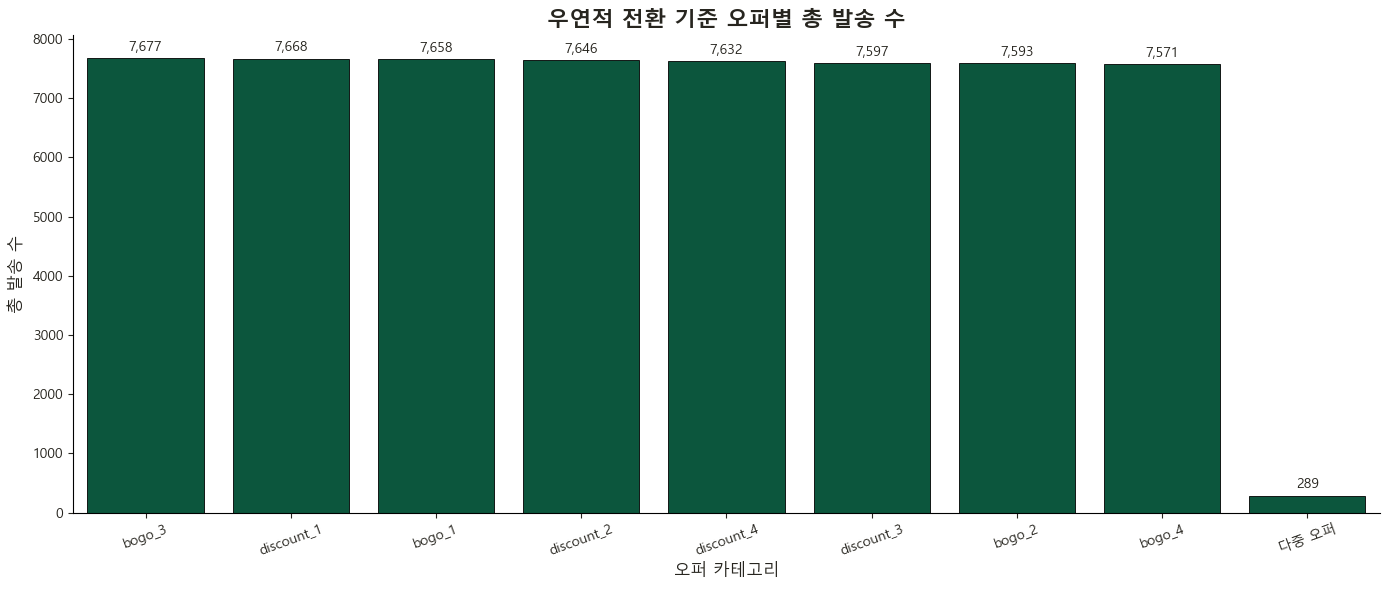

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=sent_all,
    x='offer_label',
    y='총 발송 수',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'{int(v):,}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 오퍼별 총 발송 수', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('총 발송 수', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 총 열람 수 

우연적 전환은 viewed를 거치지 않음

### 총 완료 수

In [19]:
completed_single = (
    completed_acc
    .groupby('offer_label')
    .size()
    .reset_index(name='총 완료 수')
)

# informational 제거
completed_single = completed_single[
    ~completed_single['offer_label'].str.contains('informational', na=False)
]

In [20]:
completed_multi = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 완료 수': [len(acc_tx[acc_tx['category'] == '다중 오퍼'])]
})

In [21]:
completed_all = pd.concat([completed_single, completed_multi], ignore_index=True)

completed_all = completed_all.sort_values(by='총 완료 수', ascending=False).reset_index(drop=True)

display(completed_all)

,offer_label,총 완료 수
0,discount_1,1813
1,bogo_3,1740
2,다중 오퍼,1598
3,discount_4,1455
4,bogo_1,609
5,bogo_4,428
6,discount_2,399
7,discount_3,351
8,bogo_2,290


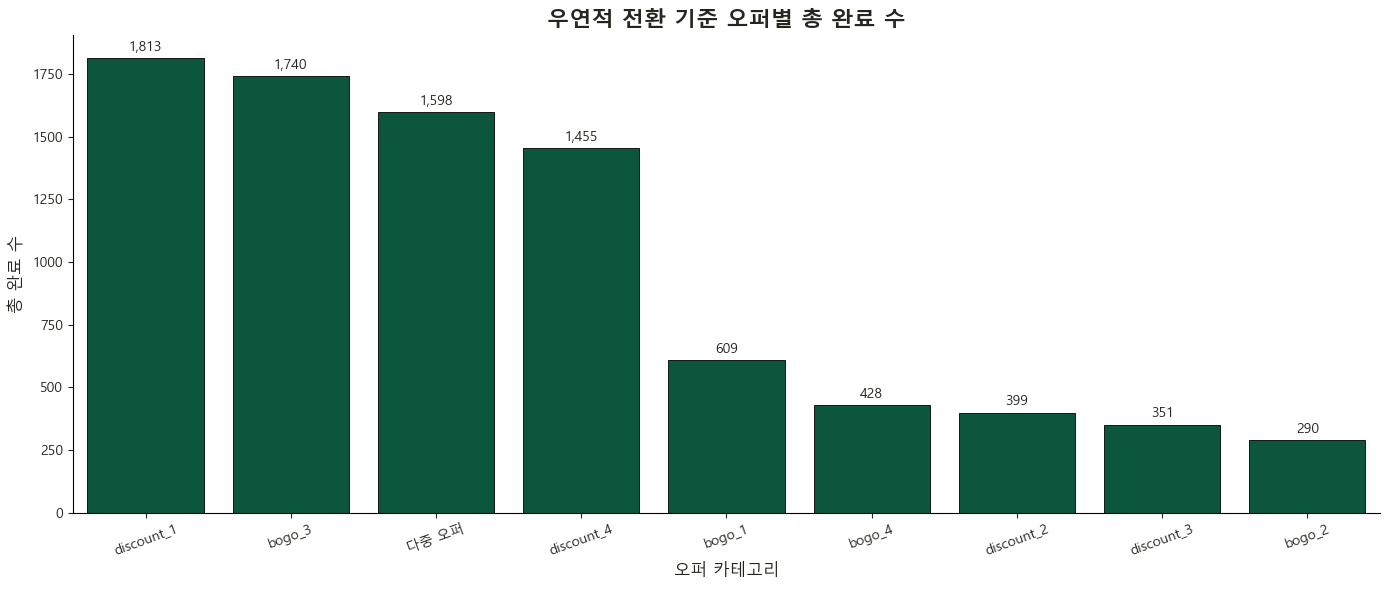

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=completed_all,
    x='offer_label',
    y='총 완료 수',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'{int(v):,}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 오퍼별 총 완료 수', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('총 완료 수', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 전체 완료율

전체 완료율 = 우연적 completed / 전체 received 수

In [23]:
# 발송 수
sent_single = (
    received_df
    .groupby('offer_label')
    .size()
    .reset_index(name='총 발송 수')
)

sent_single = sent_single[
    ~sent_single['offer_label'].str.contains('informational', na=False)
]

# 우연적 완료 수
completed_single = (
    completed_acc
    .groupby('offer_label')
    .size()
    .reset_index(name='총 완료 수')
)

completed_single = completed_single[
    ~completed_single['offer_label'].str.contains('informational', na=False)
]

# 합치기
completion_single = sent_single.merge(
    completed_single,
    on='offer_label',
    how='left'
)

completion_single['총 완료 수'] = completion_single['총 완료 수'].fillna(0)

# 완료율 계산
completion_single['완료율 (%)'] = (
    completion_single['총 완료 수'] / completion_single['총 발송 수'] * 100
)

In [24]:
# 다중 오퍼 거래 key
multi_keys = acc_tx[acc_tx['category'] == '다중 오퍼'][['person', 'time']].drop_duplicates()

# 발송 수 (전체 received 중 multi로 이어진 것)
sent_multi = received_df.merge(
    multi_keys,
    on=['person', 'time'],
    how='inner'
)

sent_multi_n = len(sent_multi)

# 완료 수 (우연적 전환 중 multi)
completed_multi_n = len(acc_tx[acc_tx['category'] == '다중 오퍼'])

# 완료율
multi_rate = (completed_multi_n / sent_multi_n * 100) if sent_multi_n > 0 else 0

In [25]:
completion_multi = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 발송 수': [sent_multi_n],
    '총 완료 수': [completed_multi_n],
    '완료율 (%)': [multi_rate]
})

completion_all = pd.concat([completion_single, completion_multi], ignore_index=True)

completion_all = completion_all.sort_values(by='완료율 (%)', ascending=False).reset_index(drop=True)

display(completion_all)

,offer_label,총 발송 수,총 완료 수,완료율 (%)
0,다중 오퍼,289,1598,552.941176
1,discount_1,7668,1813,23.643714
2,bogo_3,7677,1740,22.665104
3,discount_4,7632,1455,19.064465
4,bogo_1,7658,609,7.952468
5,bogo_4,7571,428,5.653150
6,discount_2,7646,399,5.218415
7,discount_3,7597,351,4.620245
8,bogo_2,7593,290,3.819307


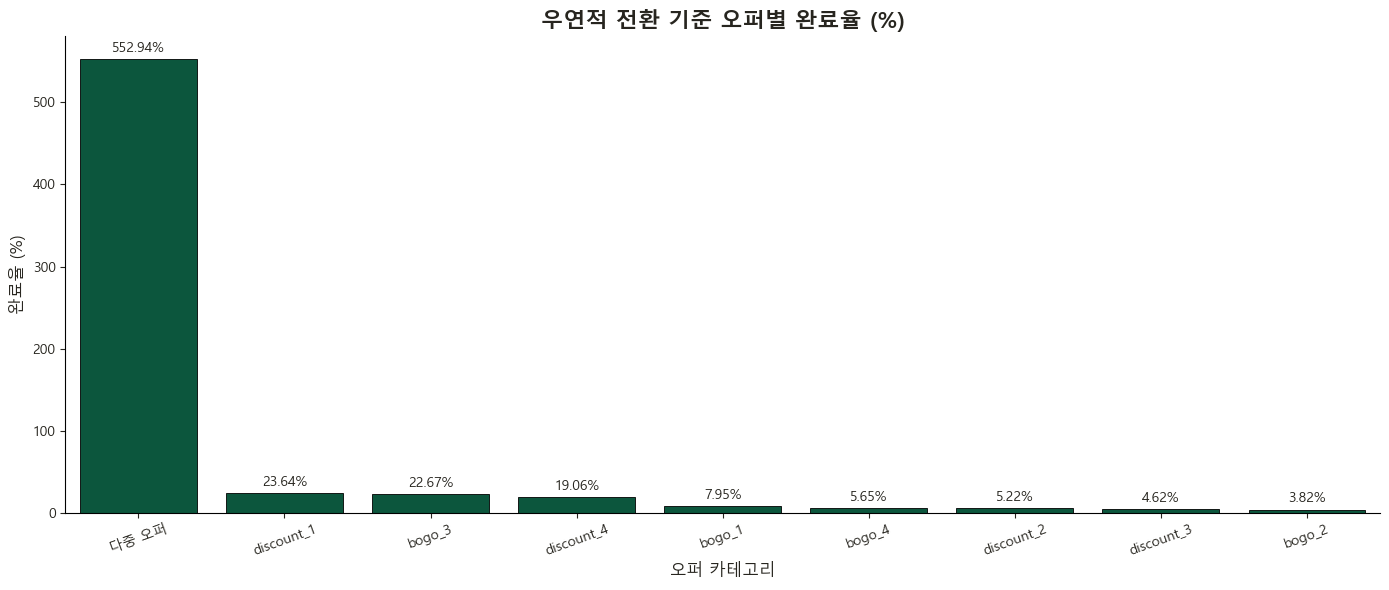

In [26]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=completion_all,
    x='offer_label',
    y='완료율 (%)',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'{v:.2f}%' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 오퍼별 완료율 (%)', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('완료율 (%)', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 총 오퍼 연계 매출

In [27]:
revenue_single = (
    acc_tx[acc_tx['category'] != '다중 오퍼']
    .groupby('offer_label')['tx_amount']
    .sum()
    .reset_index(name='총 매출')
)

In [28]:
revenue_multi = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 매출': [
        acc_tx[acc_tx['category'] == '다중 오퍼']['tx_amount'].sum()
    ]
})

In [30]:
revenue_all = pd.concat([revenue_single, revenue_multi], ignore_index=True)

revenue_all = revenue_all.sort_values(by='총 매출', ascending=False).reset_index(drop=True)

display(revenue_all)

,offer_label,총 매출
0,다중 오퍼,37968.99
1,discount_1,32243.46
2,bogo_3,24616.11
3,discount_4,22513.12
4,bogo_1,12208.15
5,discount_2,6257.00
6,bogo_4,6202.35
7,bogo_2,5172.33
8,discount_3,4718.31


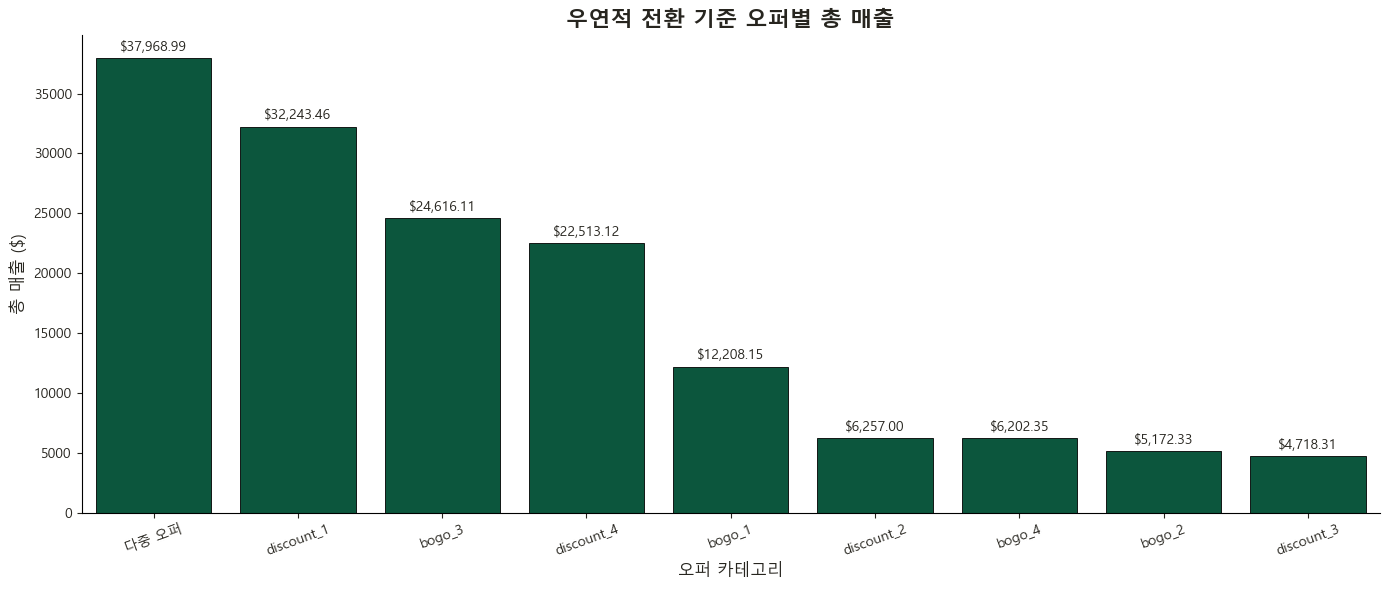

In [31]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=revenue_all,
    x='offer_label',
    y='총 매출',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'${v:,.2f}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 오퍼별 총 매출', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('총 매출 ($)', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 발송 1건당 평균 매출

In [32]:
rev_per_sent_single = sent_single.merge(
    revenue_single,
    on='offer_label',
    how='left'
)

rev_per_sent_single['총 매출'] = rev_per_sent_single['총 매출'].fillna(0)

rev_per_sent_single['발송 1건당 평균 매출'] = (
    rev_per_sent_single['총 매출'] / rev_per_sent_single['총 발송 수']
)

In [33]:
# multi 거래 key
multi_keys = acc_tx[acc_tx['category'] == '다중 오퍼'][['person', 'time']].drop_duplicates()

# 발송 수
sent_multi_n = len(received_df.merge(multi_keys, on=['person', 'time'], how='inner'))

# 매출
revenue_multi_n = acc_tx[acc_tx['category'] == '다중 오퍼']['tx_amount'].sum()

# 평균 매출
rev_per_sent_multi = revenue_multi_n / sent_multi_n if sent_multi_n > 0 else 0

In [34]:
rev_per_sent_multi_df = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 발송 수': [sent_multi_n],
    '총 매출': [revenue_multi_n],
    '발송 1건당 평균 매출': [rev_per_sent_multi]
})

rev_per_sent_all = pd.concat(
    [rev_per_sent_single, rev_per_sent_multi_df],
    ignore_index=True
)

rev_per_sent_all = rev_per_sent_all.sort_values(
    by='발송 1건당 평균 매출',
    ascending=False
).reset_index(drop=True)

display(rev_per_sent_all)

,offer_label,총 발송 수,총 매출,발송 1건당 평균 매출
0,다중 오퍼,289,37968.99,131.380588
1,discount_1,7668,32243.46,4.204937
2,bogo_3,7677,24616.11,3.206475
3,discount_4,7632,22513.12,2.949832
4,bogo_1,7658,12208.15,1.594169
5,bogo_4,7571,6202.35,0.819225
6,discount_2,7646,6257.00,0.818336
7,bogo_2,7593,5172.33,0.681197
8,discount_3,7597,4718.31,0.621075


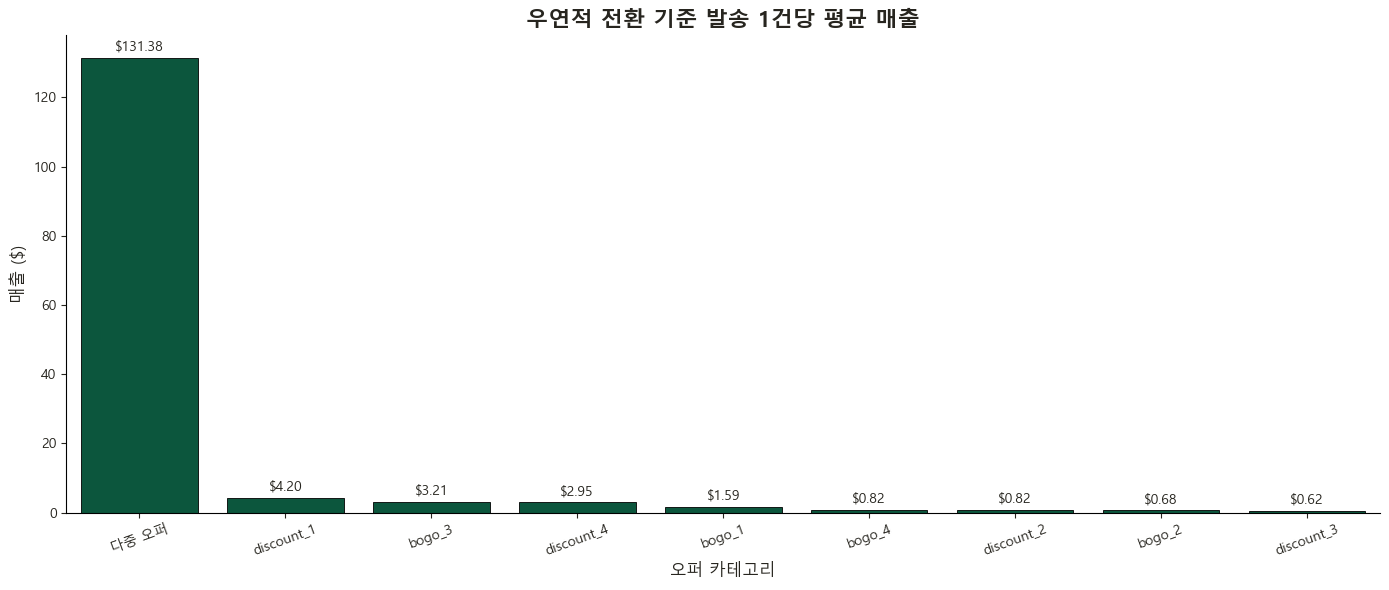

In [35]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=rev_per_sent_all,
    x='offer_label',
    y='발송 1건당 평균 매출',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'${v:,.2f}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 발송 1건당 평균 매출', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('매출 ($)', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 오퍼 완료 1건당 평균 매출

In [36]:
completed_single = (
    completed_acc
    .groupby('offer_label')
    .size()
    .reset_index(name='총 완료 수')
)

completed_single = completed_single[
    ~completed_single['offer_label'].str.contains('informational', na=False)
]

In [37]:
revenue_single = (
    acc_tx[acc_tx['category'] != '다중 오퍼']
    .groupby('offer_label')['tx_amount']
    .sum()
    .reset_index(name='총 매출')
)

In [38]:
rev_per_comp_single = completed_single.merge(
    revenue_single,
    on='offer_label',
    how='left'
)

rev_per_comp_single['총 매출'] = rev_per_comp_single['총 매출'].fillna(0)

rev_per_comp_single['완료 1건당 평균 매출'] = (
    rev_per_comp_single['총 매출'] / rev_per_comp_single['총 완료 수']
)

In [39]:
completed_multi_n = len(acc_tx[acc_tx['category'] == '다중 오퍼'])

revenue_multi_n = acc_tx[acc_tx['category'] == '다중 오퍼']['tx_amount'].sum()

rev_per_comp_multi = revenue_multi_n / completed_multi_n if completed_multi_n > 0 else 0

In [40]:
rev_per_comp_multi_df = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    '총 완료 수': [completed_multi_n],
    '총 매출': [revenue_multi_n],
    '완료 1건당 평균 매출': [rev_per_comp_multi]
})

rev_per_comp_all = pd.concat(
    [rev_per_comp_single, rev_per_comp_multi_df],
    ignore_index=True
)

rev_per_comp_all = rev_per_comp_all.sort_values(
    by='완료 1건당 평균 매출',
    ascending=False
).reset_index(drop=True)

display(rev_per_comp_all)

,offer_label,총 완료 수,총 매출,완료 1건당 평균 매출
0,다중 오퍼,1598,37968.99,23.760319
1,bogo_1,609,12208.15,20.046223
2,bogo_2,290,5172.33,17.835621
3,discount_1,1813,32243.46,17.784589
4,discount_2,399,6257.00,15.681704
5,discount_4,1455,22513.12,15.472935
6,bogo_4,428,6202.35,14.491472
7,bogo_3,1740,24616.11,14.147190
8,discount_3,351,4718.31,13.442479


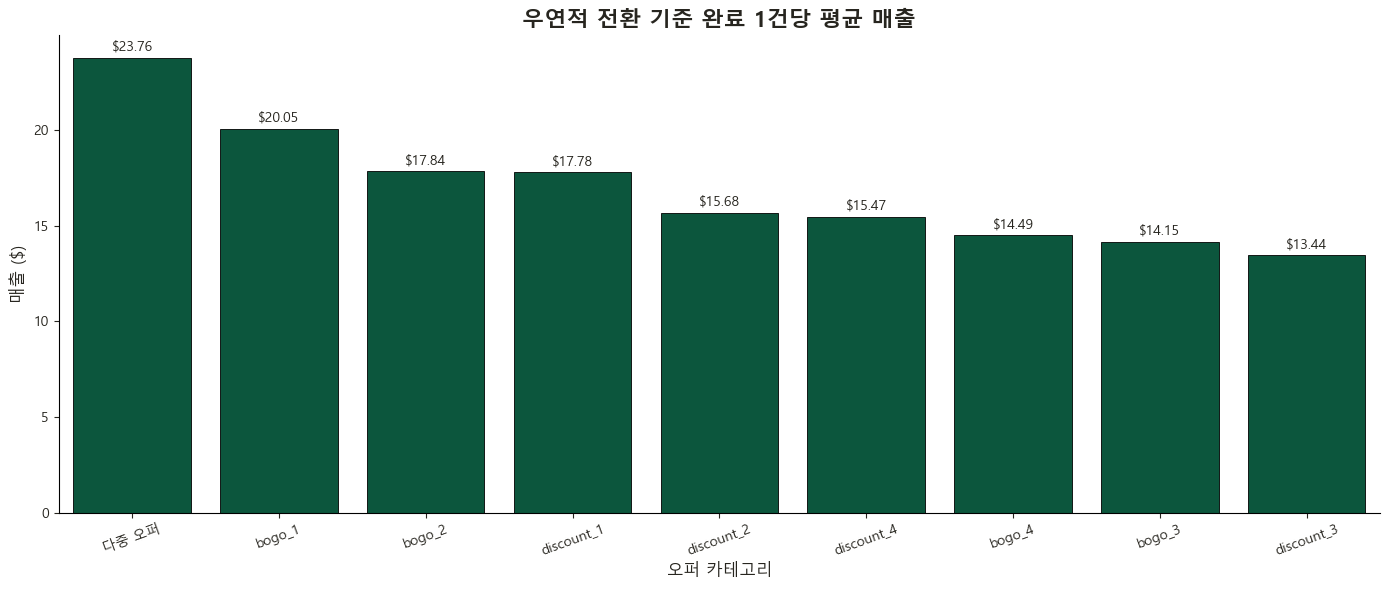

In [41]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=rev_per_comp_all,
    x='offer_label',
    y='완료 1건당 평균 매출',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'${v:,.2f}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 완료 1건당 평균 매출', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('매출 ($)', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### ARPU

In [43]:
arpu_single = (
    acc_tx[acc_tx['category'] != '다중 오퍼']
    .groupby('offer_label')
    .agg(
        total_revenue=('tx_amount', 'sum'),
        user_count=('person', 'nunique')
    )
    .reset_index()
)

arpu_single['ARPU'] = arpu_single['total_revenue'] / arpu_single['user_count']

In [44]:
multi_df = acc_tx[acc_tx['category'] == '다중 오퍼']

arpu_multi = pd.DataFrame({
    'offer_label': ['다중 오퍼'],
    'total_revenue': [multi_df['tx_amount'].sum()],
    'user_count': [multi_df['person'].nunique()]
})

arpu_multi['ARPU'] = arpu_multi['total_revenue'] / arpu_multi['user_count']

In [45]:
arpu_all = pd.concat([arpu_single, arpu_multi], ignore_index=True)

arpu_all = arpu_all.sort_values(by='ARPU', ascending=False).reset_index(drop=True)

display(arpu_all)

,offer_label,total_revenue,user_count,ARPU
0,다중 오퍼,37968.99,1352,28.083572
1,bogo_1,12208.15,461,26.481887
2,discount_1,32243.46,1227,26.278289
3,bogo_2,5172.33,243,21.285309
4,discount_4,22513.12,1078,20.884156
5,discount_2,6257.00,321,19.492212
6,bogo_3,24616.11,1316,18.705251
7,discount_3,4718.31,262,18.008817
8,bogo_4,6202.35,355,17.471408


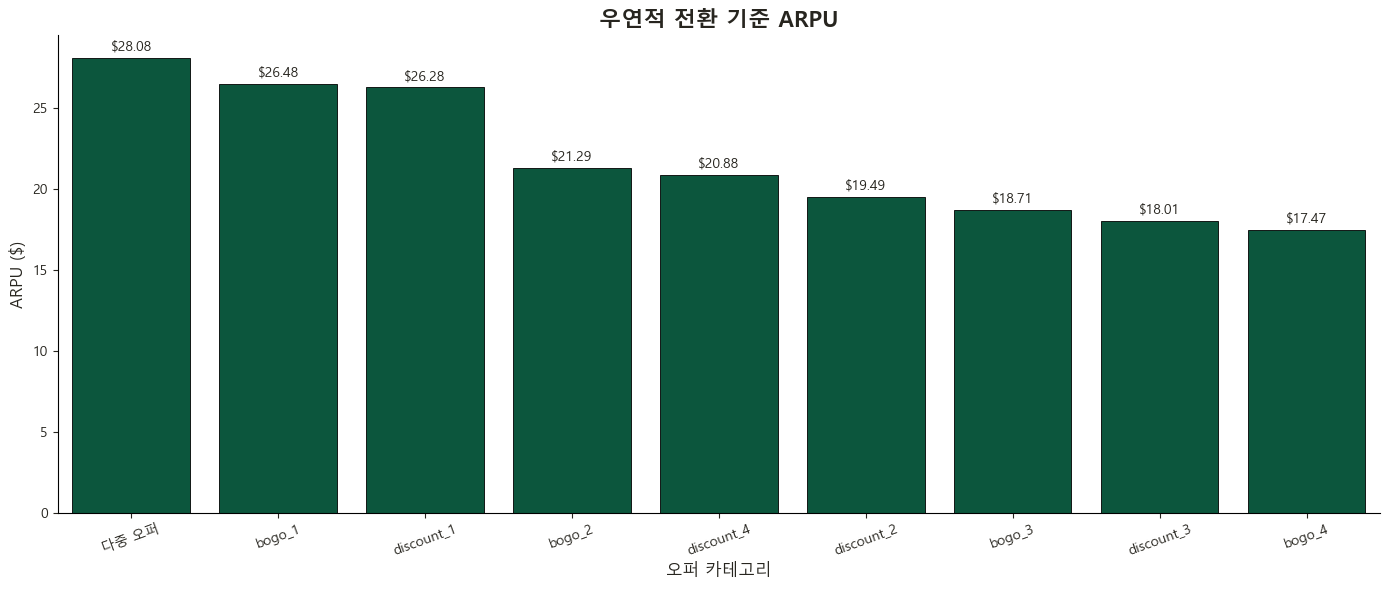

In [46]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=arpu_all,
    x='offer_label',
    y='ARPU',
    edgecolor='black',
    linewidth=0.6
)

# 값 표시
for container in ax.containers:
    labels = [f'${v:,.2f}' if pd.notnull(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('우연적 전환 기준 ARPU', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 카테고리', fontsize=12)
plt.ylabel('ARPU ($)', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()